# MiniJEPA Colab Notebook

Run this notebook in Google Colab with a GPU runtime. The workflow below installs dependencies, loads CIFAR-10 from the uploaded archive, trains MiniJEPA, and saves a qualitative prediction panel plus the checkpoint.

In [ ]:
# If you are in Google Colab, this notebook is intended to run on a GPU runtime.
# The only external input you need is the CIFAR-10 archive: cifar-10-python.tar.

!pip -q install torch torchvision matplotlib tqdm pillow

import os
import random
import tarfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from tqdm.notebook import tqdm
from torchvision import datasets, transforms



# Configuration

SEED = 42


WORKSPACE_ROOT = Path("/Users/alaabalga/Desktop/I JEPA")
DATA_DIR = WORKSPACE_ROOT / "mini_jepa" / "data"
OUTPUT_DIR = WORKSPACE_ROOT / "mini_jepa" / "outputs"


DATA_DIR = str(DATA_DIR)
OUTPUT_DIR = str(OUTPUT_DIR)

DATASET = "cifar10"
EPOCHS = 20  
BATCH_SIZE = 256  
LR = 1e-3
EMBEDDING_DIM = 512  
PATCH_SIZE = 8
EMA = 0.99
RECON_WEIGHT = 0.5  

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


set_seed(SEED)
device = get_device()
print("Device:", device)
print(f"Loading data from: {DATA_DIR}")


# No need for manual extraction - torchvision will handle it
# Just ensure the directory exists

# -----------------------------
# Data loading
# -----------------------------
def get_dataloaders(data_dir: str, batch_size: int):
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    )
    # download=True will automatically download and extract CIFAR-10 if not present
    print("Loading CIFAR-10 dataset...")
    train_set = datasets.CIFAR10(data_dir, train=True, download=True, transform=transform)
    test_set = datasets.CIFAR10(data_dir, train=False, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, test_loader, 3, 32

Device: cuda
Loading data from: /Users/alaabalga/Desktop/I JEPA/mini_jepa/data


In [15]:

# -----------------------------
# Model components
# -----------------------------
class ConvEncoder(nn.Module):
    def __init__(self, in_channels: int = 3, embedding_dim: int = 256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, embedding_dim),
            nn.LayerNorm(embedding_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(self.features(x))


class JEPAEmbeddingPredictor(nn.Module):
    def __init__(self, embedding_dim: int = 256, hidden_dim: int = 512, mask_feat_dim: int = 4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim + mask_feat_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embedding_dim),
        )

    def forward(self, context_embedding: torch.Tensor, mask_features: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([context_embedding, mask_features], dim=1))


class PatchDecoder(nn.Module):
    def __init__(self, embedding_dim: int = 256, out_channels: int = 3, patch_size: int = 8):
        super().__init__()
        self.out_channels = out_channels
        self.patch_size = patch_size
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, 1024),
            nn.GELU(),
            nn.Linear(1024, 1024),
            nn.GELU(),
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Linear(512, out_channels * patch_size * patch_size),
        )

    def forward(self, embedding: torch.Tensor) -> torch.Tensor:
        out = self.net(embedding)
        return out.view(-1, self.out_channels, self.patch_size, self.patch_size)


# -----------------------------
# Utilities
# -----------------------------
def random_mask_batch(images: torch.Tensor, patch_size: int):
    b, c, h, w = images.shape
    if patch_size > h or patch_size > w:
        raise ValueError("patch_size cannot exceed image dimensions")

    masked = images.clone()
    patches = torch.zeros((b, c, patch_size, patch_size), device=images.device)
    mask_features = torch.zeros((b, 4), device=images.device)

    for i in range(b):
        top = torch.randint(0, h - patch_size + 1, (1,), device=images.device).item()
        left = torch.randint(0, w - patch_size + 1, (1,), device=images.device).item()
        patches[i] = images[i, :, top : top + patch_size, left : left + patch_size]
        masked[i, :, top : top + patch_size, left : left + patch_size] = 0.0
        mask_features[i] = torch.tensor(
            [left / max(1, w - 1), top / max(1, h - 1), patch_size / w, patch_size / h],
            device=images.device,
        )

    return masked, patches, mask_features


def update_ema(target_model: nn.Module, source_model: nn.Module, momentum: float = 0.99) -> None:
    with torch.no_grad():
        for p_t, p_s in zip(target_model.parameters(), source_model.parameters()):
            p_t.data = momentum * p_t.data + (1.0 - momentum) * p_s.data


def denormalize(images: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor([0.5, 0.5, 0.5], device=images.device).view(1, 3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5], device=images.device).view(1, 3, 1, 1)
    return (images * std + mean).clamp(0.0, 1.0)


def reconstruct_images(masked_images: torch.Tensor, predicted_patches: torch.Tensor, mask_features: torch.Tensor):
    recon = masked_images.clone()
    b, _, h, w = masked_images.shape
    patch_size = predicted_patches.shape[-1]

    for i in range(b):
        left = int(mask_features[i, 0].item() * max(1, w - 1))
        top = int(mask_features[i, 1].item() * max(1, h - 1))
        left = min(max(0, left), w - patch_size)
        top = min(max(0, top), h - patch_size)
        recon[i, :, top : top + patch_size, left : left + patch_size] = predicted_patches[i]

    return recon


def save_prediction_panel(original, masked, predicted_patch, reconstructed, output_path: str):
    original = denormalize(original.unsqueeze(0)).squeeze(0).cpu()
    masked = denormalize(masked.unsqueeze(0)).squeeze(0).cpu()
    predicted_patch = denormalize(predicted_patch.unsqueeze(0)).squeeze(0).cpu()
    reconstructed = denormalize(reconstructed.unsqueeze(0)).squeeze(0).cpu()

    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    imgs = [original, masked, predicted_patch, reconstructed]
    titles = ["Original", "Masked", "Predicted Patch", "Reconstructed"]

    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()


Loading CIFAR-10 dataset...


Epoch 1/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 01 | avg loss: 0.461580


Epoch 2/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 02 | avg loss: 0.418774


...

Epoch 18 | avg loss: 0.228623


Epoch 19/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 19 | avg loss: 0.218874


Epoch 20/20:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 20 | avg loss: 0.215354
Saved checkpoint: /Users/alaabalga/Desktop/I JEPA/mini_jepa/outputs/mini_jepa.pt


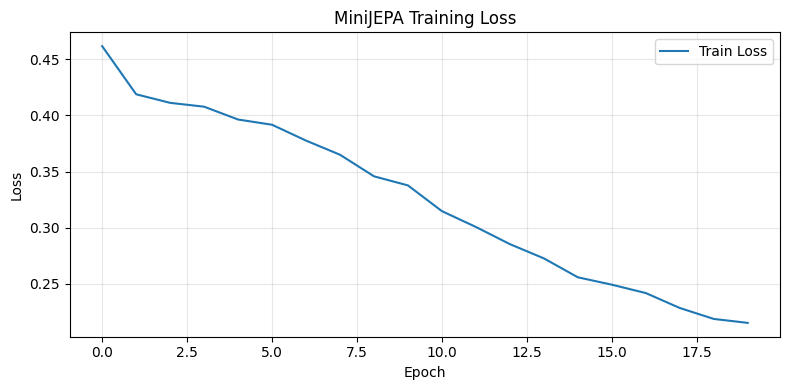

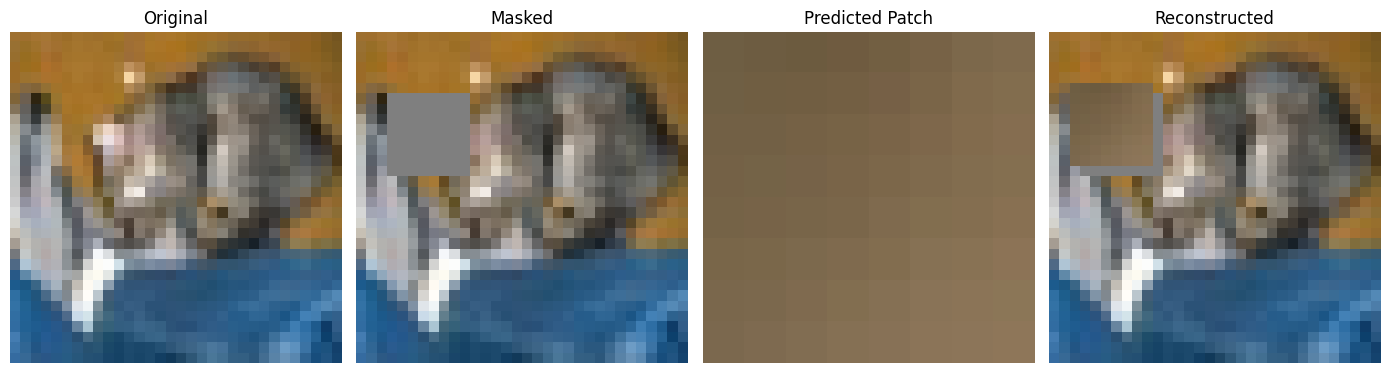

Saved loss plot: /Users/alaabalga/Desktop/I JEPA/mini_jepa/outputs/training_curve.png
Saved sample panel: /Users/alaabalga/Desktop/I JEPA/mini_jepa/outputs/sample_prediction.png
If you want, download the artifacts now:
- /Users/alaabalga/Desktop/I JEPA/mini_jepa/outputs/mini_jepa.pt
- /Users/alaabalga/Desktop/I JEPA/mini_jepa/outputs/training_curve.png
- /Users/alaabalga/Desktop/I JEPA/mini_jepa/outputs/sample_prediction.png


In [16]:

# -----------------------------
# Train / evaluate
# -----------------------------
train_loader, test_loader, channels, img_size = get_dataloaders(DATA_DIR, BATCH_SIZE)

context_encoder = ConvEncoder(in_channels=channels, embedding_dim=EMBEDDING_DIM).to(device)
target_encoder = ConvEncoder(in_channels=channels, embedding_dim=EMBEDDING_DIM).to(device)
predictor = JEPAEmbeddingPredictor(embedding_dim=EMBEDDING_DIM).to(device)
decoder = PatchDecoder(embedding_dim=EMBEDDING_DIM, out_channels=channels, patch_size=PATCH_SIZE).to(device)

target_encoder.load_state_dict(context_encoder.state_dict())
for p in target_encoder.parameters():
    p.requires_grad = False

emb_criterion = nn.MSELoss()
recon_criterion = nn.MSELoss()
optimizer = optim.Adam(
    list(context_encoder.parameters()) + list(predictor.parameters()) + list(decoder.parameters()),
    lr=LR,
)

epoch_losses = []
for epoch in range(1, EPOCHS + 1):
    context_encoder.train()
    predictor.train()
    decoder.train()

    running_loss = 0.0
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")

    for images, _ in progress:
        images = images.to(device)
        masked_images, target_patches, mask_features = random_mask_batch(images, patch_size=PATCH_SIZE)

        context_embedding = context_encoder(masked_images)
        pred_embedding = predictor(context_embedding, mask_features)

        with torch.no_grad():
            target_embedding = target_encoder(target_patches)

        pred_patch = decoder(pred_embedding)
        emb_loss = emb_criterion(pred_embedding, target_embedding)
        recon_loss = recon_criterion(pred_patch, target_patches)
        loss = emb_loss + RECON_WEIGHT * recon_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        update_ema(target_encoder, context_encoder, momentum=EMA)

        running_loss += loss.item()
        progress.set_postfix(loss=loss.item(), emb=emb_loss.item(), recon=recon_loss.item())

    avg_loss = running_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch:02d} | avg loss: {avg_loss:.6f}")


# -----------------------------
# Save checkpoint and plots
# -----------------------------
checkpoint_path = os.path.join(OUTPUT_DIR, "mini_jepa.pt")
torch.save(
    {
        "dataset": DATASET,
        "patch_size": PATCH_SIZE,
        "embedding_dim": EMBEDDING_DIM,
        "channels": channels,
        "context_encoder": context_encoder.state_dict(),
        "predictor": predictor.state_dict(),
        "decoder": decoder.state_dict(),
        "losses": epoch_losses,
    },
    checkpoint_path,
)
print("Saved checkpoint:", checkpoint_path)

plt.figure(figsize=(8, 4))
plt.plot(epoch_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MiniJEPA Training Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
loss_plot_path = os.path.join(OUTPUT_DIR, "training_curve.png")
plt.savefig(loss_plot_path)
plt.show()
plt.close()


# -----------------------------
# Sample prediction visualization
# -----------------------------
context_encoder.eval()
predictor.eval()
decoder.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    masked_images, _, mask_features = random_mask_batch(images, patch_size=PATCH_SIZE)
    context_embedding = context_encoder(masked_images)
    pred_embedding = predictor(context_embedding, mask_features)
    pred_patch = decoder(pred_embedding)
    recon = reconstruct_images(masked_images, pred_patch, mask_features)

sample_path = os.path.join(OUTPUT_DIR, "sample_prediction.png")
save_prediction_panel(
    original=images[0],
    masked=masked_images[0],
    predicted_patch=pred_patch[0],
    reconstructed=recon[0],
    output_path=sample_path,
)

print("Saved loss plot:", loss_plot_path)
print("Saved sample panel:", sample_path)


# -----------------------------
# Optional Colab downloads
# -----------------------------
try:
    from google.colab import files

    print("If you want, download the artifacts now:")
    print("-", checkpoint_path)
    print("-", loss_plot_path)
    print("-", sample_path)
except Exception:
    pass


In [17]:
# Verify the checkpoint was written to disk
import os

print("Checkpoint path:", checkpoint_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
if os.path.exists(checkpoint_path):
    print("Checkpoint size (bytes):", os.path.getsize(checkpoint_path))

Checkpoint path: /Users/alaabalga/Desktop/I JEPA/mini_jepa/outputs/mini_jepa.pt
Checkpoint exists: True
Checkpoint size (bytes): 17100019


In [18]:
# Re-save the trained checkpoint into the workspace so the website can load it
import os
import torch

checkpoint_path = os.path.join(OUTPUT_DIR, "mini_jepa.pt")
torch.save(
    {
        "dataset": DATASET,
        "patch_size": PATCH_SIZE,
        "embedding_dim": EMBEDDING_DIM,
        "channels": channels,
        "context_encoder": context_encoder.state_dict(),
        "predictor": predictor.state_dict(),
        "decoder": decoder.state_dict(),
        "losses": epoch_losses,
    },
    checkpoint_path,
)
print("Re-saved checkpoint:", checkpoint_path)
print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("Checkpoint size (bytes):", os.path.getsize(checkpoint_path) if os.path.exists(checkpoint_path) else 0)

Re-saved checkpoint: /Users/alaabalga/Desktop/I JEPA/mini_jepa/outputs/mini_jepa.pt
Checkpoint exists: True
Checkpoint size (bytes): 17100019
